In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from nig_beta_overlap_utils import (
    standard_posterior_params,
    beta_bayes_posterior_grid,
    hellinger_1d_gaussian,
)

np.random.seed(8881991)


In [2]:
mu_true = 0.0
s2_true = 1.5

sigma2_model = 0.5

mu0 = 0.0
tau2 = 1.5
beta = 1.64


In [3]:
theta_grid = np.linspace(-2, 2, 5000)
dtheta = theta_grid[1] - theta_grid[0]


In [4]:
# Generate well-specified threshold and store pairs for reuse
# Sample 1000 independent pairs of datasets from TRUE DGP
# For each pair, compute posteriors using CORRECT model (sigma2 = s2_true)
# and their discrepancy using CLOSED FORM
# Average discrepancy = well-specified threshold

rng_shared = np.random.default_rng(556564)
T_outer = 1000
m = 1000  # Size of each dataset in a pair

# Generate pairs ONCE and store them
paired_datasets = []
d_half_vals_threshold = []

for _ in range(T_outer):
    # Generate two independent datasets from TRUE DGP
    x_data = rng_shared.normal(loc=mu_true, scale=np.sqrt(s2_true), size=m)
    y_data = rng_shared.normal(loc=mu_true, scale=np.sqrt(s2_true), size=m)
    paired_datasets.append((x_data, y_data))

    # Compute posterior parameters analytically (CLOSED FORM)
    mu_A, var_A = standard_posterior_params(x_data, mu0, tau2, s2_true)
    mu_B, var_B = standard_posterior_params(y_data, mu0, tau2, s2_true)

    # Compute d_{1/2} using closed-form formula
    d_half = hellinger_1d_gaussian(mu_A, var_A, mu_B, var_B)
    d_half_vals_threshold.append(d_half)

# Well-specified threshold = average d_{1/2} across all pairs
threshold = np.mean(d_half_vals_threshold)
print(f"Well-specified threshold (correct model, sigma2={s2_true}): {threshold:.4f}")


Well-specified threshold (correct model, sigma2=1.5): 0.4827


In [5]:
# Compute observed discrepancies using the SAME pairs from the threshold computation
# Use closed-form for standard Bayes (Gaussian), grid-based for beta-Bayes (non-Gaussian)

d_half_vals_real_beta = []
d_half_vals_real_nll = []

for (x_data, y_data) in paired_datasets:
    # Beta-Bayes (grid-based, since it's non-Gaussian)
    pA = beta_bayes_posterior_grid(x_data, theta_grid, beta=beta,
                                   sigma2=sigma2_model, mu0=mu0, tau2=tau2)
    pB = beta_bayes_posterior_grid(y_data, theta_grid, beta=beta,
                                   sigma2=sigma2_model, mu0=mu0, tau2=tau2)
    affinity = np.trapz(np.sqrt(pA * pB), theta_grid)
    d_half_vals_real_beta.append(-2 * np.log(affinity))

    # Standard Bayes (closed-form, both are Gaussians)
    mu_A_nll, var_A_nll = standard_posterior_params(x_data, mu0, tau2, sigma2_model)
    mu_B_nll, var_B_nll = standard_posterior_params(y_data, mu0, tau2, sigma2_model)
    d_half = hellinger_1d_gaussian(mu_A_nll, var_A_nll, mu_B_nll, var_B_nll)
    d_half_vals_real_nll.append(d_half)

# Compute averages across all pairs
d_half_real = np.mean(d_half_vals_real_beta)
d_half_real_nll = np.mean(d_half_vals_real_nll)

print(f"Well-specified threshold (Standard Bayes): {threshold:.4f}")
print(f"Observed discrepancy with β-Bayes (mean over {T_outer} pairs):       {d_half_real:.4f}")
print(f"Observed discrepancy with Standard Bayes (mean over {T_outer} pairs): {d_half_real_nll:.4f}")


/tmp/claude-501/ipykernel_34826/2936579084.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  affinity = np.trapz(np.sqrt(pA * pB), theta_grid)


Well-specified threshold (Standard Bayes): 0.4827
Observed discrepancy with β-Bayes (mean over 1000 pairs):       0.4881
Observed discrepancy with Standard Bayes (mean over 1000 pairs): 1.4491


In [6]:
def gap(beta):
    # Compute average β-Bayes discrepancy across the paired datasets
    d_half_vals_beta = []
    for (x_data, y_data) in paired_datasets:
        pA = beta_bayes_posterior_grid(x_data, theta_grid, beta, sigma2_model, mu0, tau2)
        pB = beta_bayes_posterior_grid(y_data, theta_grid, beta, sigma2_model, mu0, tau2)
        affinity = np.trapz(np.sqrt(pA * pB), theta_grid)
        d_half_vals_beta.append(-2 * np.log(affinity))
    actual_avg = np.mean(d_half_vals_beta)
    return actual_avg - threshold

# Test endpoints and get actual discrepancies
print(f"Threshold (well-specified):        {threshold:.4f}")
print(f"Observed β-Bayes β={beta}:         {d_half_real:.4f}")
print()

gap_low = gap(1.65)
gap_high = gap(1.66)
print(f"gap(1.65) = {gap_low:.4f} (should be > 0)")
print(f"gap(1.66)  = {gap_high:.4f} (should be < 0)")
print()

if gap_low * gap_high < 0:
    print("✓ Sign change detected, proceeding with brentq...")
    beta_star = brentq(gap, 1.65, 1.66, xtol=1e-3)
    print(f"β* = {beta_star:.4f}")

    # Verify
    gap_star = gap(beta_star)
    print(f"gap(β*) = {gap_star:.6f} (should be ≈ 0)")
else:
    print("✗ No sign change in interval [1.65, 1.66]")
    print("  Try expanding the bracket manually or check threshold computation")


Threshold (well-specified):        0.4827
Observed β-Bayes β=1.64:         0.4881



/tmp/claude-501/ipykernel_34826/2073344523.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  affinity = np.trapz(np.sqrt(pA * pB), theta_grid)


gap(1.65) = 0.0010 (should be > 0)
gap(1.66)  = -0.0032 (should be < 0)

✓ Sign change detected, proceeding with brentq...


β* = 1.6525


gap(β*) = -0.000006 (should be ≈ 0)


/tmp/claude-501/ipykernel_34826/3834288646.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aff = np.trapz(np.sqrt(pA * pB), theta_grid)


  beta=1.001  d_1/2=1.2688


  beta=1.054  d_1/2=1.0371


  beta=1.106  d_1/2=0.9020


  beta=1.159  d_1/2=0.8105


...

  beta=1.790  d_1/2=0.3920


  beta=1.842  d_1/2=0.3740


  beta=1.895  d_1/2=0.3573


  beta=1.947  d_1/2=0.3416


  beta=2.000  d_1/2=0.3269


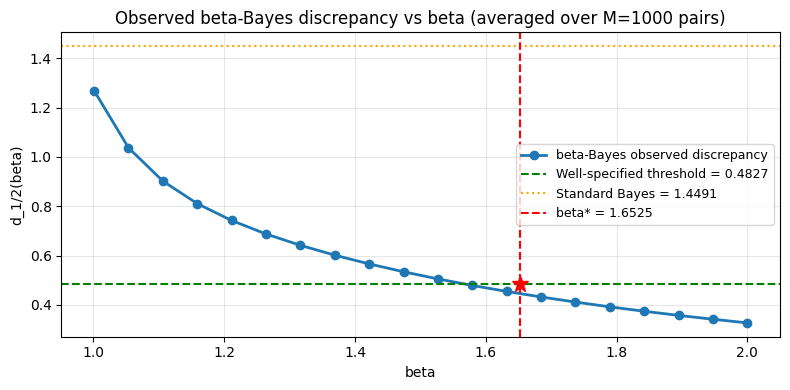

In [7]:
# Sweep beta in (1, 2] and plot the average d_{1/2} vs beta (Figure 4).
# This is a supplementary visualization only -- Table 1's reported numbers come
# from the separate threshold / observed-discrepancy / beta* cells above, which
# use the full M=1000 pairs. For plotting smoothness at reasonable cost, this
# sweep uses a subset of M_PLOT pairs and a coarser beta grid; this has no effect
# on any reported statistic, only on how smooth the illustrative curve looks.
M_PLOT = 200
beta_sweep = np.linspace(1.001, 2.0, 20)
d_half_sweep = []

for b_val in beta_sweep:
    vals = []
    for (x_data, y_data) in paired_datasets[:M_PLOT]:
        pA = beta_bayes_posterior_grid(x_data, theta_grid, b_val, sigma2_model, mu0, tau2)
        pB = beta_bayes_posterior_grid(y_data, theta_grid, b_val, sigma2_model, mu0, tau2)
        aff = np.trapz(np.sqrt(pA * pB), theta_grid)
        vals.append(-2.0 * np.log(np.clip(aff, 1e-300, 1.0)))
    d_half_sweep.append(np.mean(vals))
    print(f"  beta={b_val:.3f}  d_1/2={d_half_sweep[-1]:.4f}")

d_half_sweep = np.array(d_half_sweep)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(beta_sweep, d_half_sweep, "o-", lw=2, label="beta-Bayes observed discrepancy")
ax.axhline(threshold, color="green", linestyle="--", lw=1.5, label=f"Well-specified threshold = {threshold:.4f}")
ax.axhline(d_half_real_nll, color="orange", linestyle=":", lw=1.5, label=f"Standard Bayes = {d_half_real_nll:.4f}")

# Mark beta* if available
try:
    ax.axvline(beta_star, color="red", linestyle="--", lw=1.5, label=f"beta* = {beta_star:.4f}")
    ax.plot(beta_star, threshold, "r*", ms=12)
except NameError:
    pass

ax.set_xlabel("beta")
ax.set_ylabel("d_1/2(beta)")
ax.set_title("Observed beta-Bayes discrepancy vs beta (averaged over M=1000 pairs)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


In [8]:
# Monte Carlo standard errors for the three main discrepancy summaries
def mc_se(values):
    values = np.asarray(values, dtype=float)
    if values.size < 2:
        return 0.0
    return np.std(values, ddof=1) / np.sqrt(values.size)

# Threshold and standard Bayes SEs reuse precomputed per-pair values
se_threshold = mc_se(d_half_vals_threshold)
se_std = mc_se(d_half_vals_real_nll)

# Compute beta-Bayes discrepancy/SE at beta* when available
beta_for_se = beta_star if 'beta_star' in globals() else beta
d_half_vals_real_beta_at_target = []
for (x_data, y_data) in paired_datasets:
    pA = beta_bayes_posterior_grid(x_data, theta_grid, beta_for_se, sigma2_model, mu0, tau2)
    pB = beta_bayes_posterior_grid(y_data, theta_grid, beta_for_se, sigma2_model, mu0, tau2)
    affinity = np.trapz(np.sqrt(pA * pB), theta_grid)
    d_half_vals_real_beta_at_target.append(-2.0 * np.log(np.clip(affinity, 1e-300, 1.0)))

se_beta_target = mc_se(d_half_vals_real_beta_at_target)

print("Standard errors (across paired datasets):")
print(f"  Well-specified threshold d*_1/2: mean={np.mean(d_half_vals_threshold):.4f}, SE={se_threshold:.6f}")
print(f"  Standard Bayes observed d_1/2:   mean={np.mean(d_half_vals_real_nll):.4f}, SE={se_std:.6f}")
print(f"  Beta-Bayes observed d_1/2 at beta={beta_for_se:.4f}: mean={np.mean(d_half_vals_real_beta_at_target):.4f}, SE={se_beta_target:.6f}")


/tmp/claude-501/ipykernel_34826/1129977577.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  affinity = np.trapz(np.sqrt(pA * pB), theta_grid)


Standard errors (across paired datasets):
  Well-specified threshold d*_1/2: mean=0.4827, SE=0.022189
  Standard Bayes observed d_1/2:   mean=1.4491, SE=0.066612
  Beta-Bayes observed d_1/2 at beta=1.6525: mean=0.4827, SE=0.021201
